# Question being answered?
## Setup

In [1]:
import pandas as pd
import numpy as np
from scripts.data_processing.storage import load_parquet_df
import requests
import matplotlib.pyplot as plt

In [2]:
players_df = load_parquet_df("silver_players.parquet")

In [12]:
list(players_df.columns)

['account_id',
 'hero_id',
 'player_slot',
 'team',
 'kills',
 'deaths',
 'assists',
 'net_worth',
 'last_hits',
 'denies',
 'ability_points',
 'assigned_lane',
 'player_level',
 'power_up_buffs',
 'hero_release_votes',
 'player_match_outcome',
 'final_stats.ability_kills',
 'final_stats.ability_points',
 'final_stats.absorption_provided',
 'final_stats.assists',
 'final_stats.boss_damage',
 'final_stats.bullet_kills',
 'final_stats.creep_damage',
 'final_stats.creep_kills',
 'final_stats.damage_absorbed',
 'final_stats.damage_mitigated',
 'final_stats.deaths',
 'final_stats.denies',
 'final_stats.gold_boss',
 'final_stats.gold_boss_orb',
 'final_stats.gold_death_loss',
 'final_stats.gold_denied',
 'final_stats.gold_lane_creep',
 'final_stats.gold_lane_creep_orbs',
 'final_stats.gold_neutral_creep',
 'final_stats.gold_neutral_creep_orbs',
 'final_stats.gold_player',
 'final_stats.gold_player_orbs',
 'final_stats.gold_treasure',
 'final_stats.headshot_kills',
 'final_stats.heal_lost',
 

In [3]:
players_df["match_outcome_binary"] = players_df["player_match_outcome"].map({"Win": 1, "Loss": 0})
players_df["is_mvp"] = players_df["mvp_rank"].notna().astype(int)

In [4]:
BASE = "https://api.deadlock-api.com"
HEADERS = {"User-Agent": "python-requests (deadlock-exploration-script)"}

r = requests.get(f"{BASE}/v1/assets/heroes", headers=HEADERS, timeout=30)
r.raise_for_status()
hero_names = pd.DataFrame(r.json())[["id", "name"]].rename(columns={"id": "hero_id", "name": "hero_name"})

players_df = players_df.merge(hero_names, on="hero_id", how="left")

## Full evaluation pipeline

Take your logistic regression model.
- Split your data — Train the model on one chunk (train set), test it on another chunk it's never seen (test set). This keeps your evaluation honest instead of grading yourself on the homework you already saw the answers to. (Done)
- Cross-validate — Instead of relying on just one lucky (or unlucky) split, repeat the train/test process several times on different slices of the data (e.g., 5-fold cross-validation) and average the results. This tells you the model is reliably good, not just good on one particular split.
- Plot an ROC curve — This shows how well your model tells the two classes apart across every possible decision threshold, not just the default 0.5 cutoff.
- Calculate AUC — One number that summarizes the whole ROC curve. 1.0 = perfect model, 0.5 = no better than a coin flip.

Done:
-   You report sensitivity and specificity at two different thresholds (not just 0.5)
    and explain the tradeoff in language a non-technical stakeholder could act on.
-   Watch for: High AUC with a badly chosen operating threshold is still a bad deployed model — AUC measures the curve, not your    actual decision point.

In [5]:
players_df.columns

Index(['account_id', 'hero_id', 'player_slot', 'team', 'kills', 'deaths',
       'assists', 'net_worth', 'last_hits', 'denies', 'ability_points',
       'assigned_lane', 'player_level', 'power_up_buffs', 'hero_release_votes',
       'player_match_outcome', 'final_stats.ability_kills',
       'final_stats.ability_points', 'final_stats.absorption_provided',
       'final_stats.assists', 'final_stats.boss_damage',
       'final_stats.bullet_kills', 'final_stats.creep_damage',
       'final_stats.creep_kills', 'final_stats.damage_absorbed',
       'final_stats.damage_mitigated', 'final_stats.deaths',
       'final_stats.denies', 'final_stats.gold_boss',
       'final_stats.gold_boss_orb', 'final_stats.gold_death_loss',
       'final_stats.gold_denied', 'final_stats.gold_lane_creep',
       'final_stats.gold_lane_creep_orbs', 'final_stats.gold_neutral_creep',
       'final_stats.gold_neutral_creep_orbs', 'final_stats.gold_player',
       'final_stats.gold_player_orbs', 'final_stats.gold_tre

In [6]:
players_df

,account_id,hero_id,player_slot,team,kills,deaths,assists,net_worth,last_hits,denies,...,final_stats.teammate_barriering,final_stats.teammate_healing,final_stats.tech_power,final_stats.time_stamp_s,final_stats.weapon_power,mvp_rank,match_id,match_outcome_binary,is_mvp,hero_name
0,360469427,65,7,Team1,2,0,0,5432,41,0,...,0,0,9,513,36,2.0,109247679,1,1,Venator
1,1721769118,35,11,Team1,1,0,0,5344,44,8,...,0,553,25,513,23,1.0,109247679,1,1,Viscous
2,107223731,66,10,Team1,1,1,0,6316,56,6,...,0,0,40,513,0,NaN,109247679,1,0,Victor
3,1077217912,67,8,Team1,0,0,2,5442,25,0,...,357,214,9,513,17,NaN,109247679,1,0,Paige
4,1279560098,64,12,Team1,0,0,1,5423,24,1,...,0,0,9,513,9,NaN,109247679,1,0,Drifter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11689,1561832611,35,5,Team0,6,8,14,51910,251,2,...,0,1138,156,2854,72,NaN,109179232,0,0,Viscous
11690,81048852,72,6,Team0,4,4,17,52985,169,2,...,0,0,103,2854,88,NaN,109179232,0,0,Billy
11691,158377514,80,4,Team0,5,8,8,51674,168,5,...,0,0,103,2854,147,NaN,109179232,0,0,Silver
11692,167231511,81,7,Team1,6,6,13,49070,168,5,...,0,0,179,2854,60,NaN,109179232,1,0,Celeste


In [7]:
# players_df = players_df[players_df["is_mvp"] == True]

## Sklearn Logistic Regression

In [8]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate
from sklearn.impute import SimpleImputer



print(len(players_df))
independent_cols = [
    "kills",
    "deaths",
    "assists",
    "player_slot",
    # "player_level",
    "last_hits",
    "denies",
    # "ability_points",
    # "final_stats.ability_kills",
    # "final_stats.absorption_provided",
    # "final_stats.creep_damage",
    # "final_stats.creep_kills",
    # "final_stats.damage_absorbed",
    # "final_stats.damage_mitigated",
    # "final_stats.gold_death_loss",
    # "final_stats.gold_denied",
    # "final_stats.headshot_kills",
    # "final_stats.heal_lost",
    # "final_stats.heal_prevented",
    # "final_stats.hero_bullets_hit",
    # "final_stats.hero_bullets_hit_crit",
    # "final_stats.max_health",
    # "final_stats.melee_kills",
    # "final_stats.neutral_damage",
    # "final_stats.neutral_kills",
    # "final_stats.player_barriering",
    # "final_stats.player_damage",
    # "final_stats.player_damage_taken",
    # "final_stats.player_healing",
    # "final_stats.possible_creeps",
    # "final_stats.self_damage",
    # "final_stats.self_healing",
    # "final_stats.shots_hit",
    # "final_stats.shots_missed",
    # "final_stats.teammate_barriering",
    # "final_stats.teammate_healing",
    # "final_stats.tech_power",
    # "final_stats.weapon_power",
]




X = players_df[independent_cols]
y = players_df["match_outcome_binary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) # Whats random state?

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')), # <-- Add this first!
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression())
])

scoring_metrics = ['accuracy', 'precision', 'recall', 'f1']
scores = cross_validate(pipeline, X_train, y_train, cv=5, scoring=scoring_metrics)

print("Sandbox Mean Accuracy:", scores['test_accuracy'].mean())
print("Mean F1-Score:", scores['test_f1'].mean())

pipeline.fit(X, y)

weights = pipeline.named_steps['log_reg'].coef_[0]
feature_importance = dict(zip(X.columns, weights))

sorted_features = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)

print("Impact on winning (Highest to Lowest)")
for feature, weight in sorted_features:
    print(f"{feature}: {weight:.4f}")

11694
Sandbox Mean Accuracy: 0.816860109957239
Mean F1-Score: 0.8212880777066129
Impact on winning (Highest to Lowest)
assists: 1.4916
kills: 0.6792
denies: 0.0203
player_slot: -0.1176
last_hits: -0.1857
deaths: -1.3096


## Plotting ROC Curve

0.897648481298401


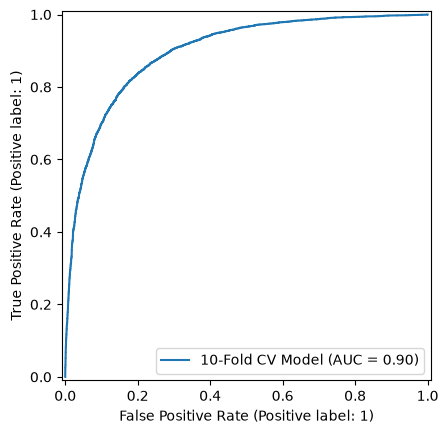

In [9]:
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score

y_probabilities = cross_val_predict(pipeline, X, y, cv=10, method='predict_proba')

auc_score = roc_auc_score(y, y_probabilities[:, 1])
print(auc_score)

RocCurveDisplay.from_predictions(y, y_probabilities[:, 1], name="10-Fold CV Model")
plt.show()

# NOT DONE!

A21. Calibration audit
●●○ Applied · ~2 hrs · Prereq: A19

Task: Plot a calibration curve (reliability diagram) for the model you evaluated in A19.
If it's off, fix it with Platt scaling or isotonic regression (sklearn.calibration).
Done: You've identified whether the model is over- or under-confident, and the Brier score measurably improves after correction. Watch for: A model can have great AUC and terrible calibration at once — AUC only cares about ranking, not whether "70% confident" actually means 70%.

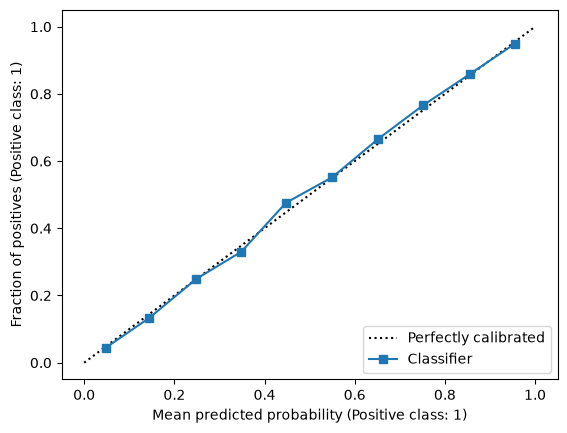

In [10]:
from sklearn.model_selection import cross_val_predict

y_probas_cv = cross_val_predict(
    pipeline, X_train, y_train, cv=5, method="predict_proba"
)
winning_confidence_cv = y_probas_cv[:, 1]

from sklearn.calibration import CalibrationDisplay

# This replaces the math, the binning, and all your manual plt.plot lines!
CalibrationDisplay.from_predictions(y_train, winning_confidence_cv, n_bins=10)

plt.show()


A22. Cost-sensitive threshold tuning
●●○ Applied · ~1–2 hrs · Prereq: A19

Task: Using the model and predictions from A19, define a real cost for false positives vs. false negatives in your domain (e.g., a bad recommendation vs. a missed good one). Find the threshold that minimizes expected cost, not accuracy. Done: You show expected cost at the default 0.5 threshold vs. your optimized threshold, and the optimized one wins. Watch for: The "optimal" threshold is only as good as your cost numbers — if you can't defend where they came from, say so honestly in your write-up.

Two cost numbers. One for a false positive and one for a false negative, with a sentence on where each came from. If they're guesses, say so.

False positive: The model predicited a match was won when it wasn't. Provides wrong analytics for players to decide what to do in game.
False negitive: The model predicited a match was lost when it wasn't.  Provides wrong analytics for players to decide what not to do in a game.

In [11]:
import numpy as np

y_prob_test = pipeline.predict_proba(X_test)[:, 1]
y_test = np.asarray(y_test)

C_FP = 1   # predicted win, wasn't
C_FN = 3   # predicted loss, was actually a win (your estimate)

def expected_cost(y, probs, t, c_fp, c_fn):
    pred = probs >= t
    fp = ((pred == 1) & (y == 0)).sum()
    fn = ((pred == 0) & (y == 1)).sum()
    return (fp * c_fp + fn * c_fn) / len(y)   # cost per prediction

ts = np.linspace(0.01, 0.99, 99)
costs = [expected_cost(y_test, y_prob_test, t, C_FP, C_FN) for t in ts]
best_t = ts[np.argmin(costs)]

print("cost at 0.5:", expected_cost(y_test, y_prob_test, 0.5, C_FP, C_FN))
print(f"cost at {best_t:.2f}:", expected_cost(y_test, y_prob_test, best_t, C_FP, C_FN))

win_rate = y_test.mean()
print("always predict win (t=0.01): ", costs[0])
print("always predict loss (t=0.99):", costs[-1])
print("model at best threshold:     ", min(costs))

cost at 0.5: 0.35622684525505843
cost at 0.22: 0.2798518096323739
always predict win (t=0.01):  0.4781989170703904
always predict loss (t=0.99): 1.4291821031632943
model at best threshold:      0.2798518096323739
